# P.10. CTD Optionality in Treasury Futures via Rate Trees


## Edits

| Date | Change |
|------|--------|
| 2026-03-05 | Updated GSW curve data from `gsw_params_2026-02-20.xlsx` to `gsw_params_2026-02-27.xlsx`, reducing the gap between the curve date and the bond data date (Mar 2) from 10 calendar days to 3. |
| 2026-03-05 | Added `bdt_numpy.py` (BDT tree calibration and delivery option code) to the Box data folder. Added `price_bond_textbook` helper to the Resources section. Updated Q2/Q3 references accordingly. |
| 2026-03-05 | Reworded Q2d to clarify intent: the question asks whether the tree's terminal states produce meaningful CTD switching, not for a direct comparison between short rates and bond YTMs. |
| 2026-03-05 | Q1b now uses parallel shifts to the GSW zero-coupon (spot) curve instead of shifting individual bond YTMs. This is consistent with Q4b and with the standard definition of duration. Added note to Q1a that the CTD is near-tied and may differ from Bloomberg's (which uses implied repo rate). |
| 2026-03-05 | Q2a: clarified that Svensson yields are in percent and the discount factor formula needs `/100`. |
| 2026-03-05 | Q3c: replaced "median terminal state" with the explicit state index (state 8 of 0–16). |
| 2026-03-05 | Added US (classic bond) to `treasury_basis.xlsx`. Q5a now uses US basis history directly instead of TY as a proxy. Data Files table updated accordingly. |
| 2026-03-05 | Q6b: removed specific bond counts and duration ranges to avoid giving away the ranking. |

## 1. Project Statement

Model the delivery option embedded in Treasury futures using a calibrated BDT interest rate tree, quantify its value across rate scenarios and volatility regimes, and compare to observed market basis. Using the US classic bond future (USM6, June 2026 delivery) with its basket of 59 deliverable bonds spanning durations of 11–19 years, investigate when and why the CTD switches, how the delivery option value depends on volatility and yield levels, and what the historical basis tells us about the limits of the tree-based model during repo market stress.


## 2. Context

### Why Practitioners Care

The Treasury futures basis trade is one of the largest and most closely watched positions in fixed income. Hedge funds run leveraged long-cash/short-futures trades to capture the basis, which in normal times is a few 32nds. Understanding what drives the basis requires decomposing it into its components: carry, delivery optionality, and funding costs.

### Futures Pricing and the Delivery Option

Treasury futures allow the short to deliver any bond from a basket of eligible securities. Each bond has a **conversion factor** (CF) designed so that all bonds would be equally cheap to deliver at a 6% yield. At any other yield, one bond is cheapest:

$$\text{Invoice Price} = \text{Futures Price} \times \text{CF}_i + \text{Accrued Interest}_i$$

The short chooses the bond $i$ that minimizes the cost of delivery:

$$\text{CTD} = \arg\min_i \frac{\text{Clean Price}_i}{\text{CF}_i}$$

The **delivery option** arises because the CTD identity can change as rates move before delivery. This switching optionality has value to the short and depresses the futures price:

$$\text{Futures Price} = \mathbb{E}\left[\min_i \frac{P_i(T_{\text{del}})}{\text{CF}_i}\right] < \frac{\mathbb{E}[P_{\text{CTD}}(T_{\text{del}})]}{\text{CF}_{\text{CTD}}}$$

This is an **option on the minimum** of a basket — there is no closed-form solution, which is exactly why numerical methods (trees, Monte Carlo) are needed. The option value tends to be largest for contracts with **wide deliverable baskets** (many bonds, large duration/coupon dispersion) — which is why we study the classic bond (US) contract with its 59 deliverables rather than the 10-year note (TY) with its narrow 9-bond basket.

### The Basis

The **gross basis** is the difference between the cash bond price and the futures-implied price:

$$\text{Gross Basis} = P_{\text{CTD}} - F \times \text{CF}_{\text{CTD}} \approx \text{Carry} + \text{Delivery Option Value}$$

The **net basis** removes carry, isolating the delivery option plus any residual:

$$\text{Net Basis} = \text{Gross Basis} - \text{Carry} \approx \text{Delivery Option Value}$$

In theory, the net basis should track the delivery option value. In practice, the relationship is less clean — understanding when and why the net basis departs from model-implied option value is a central question for this project.

### BDT Tree Calibration

The Black-Derman-Toy (BDT) model produces a binomial tree of short rates calibrated to match discount factors and volatility. We calibrate the tree to the **GSW Treasury zero-coupon curve** (Gürkaynak-Sack-Wright Svensson parameters, published by the Federal Reserve) so that model bond prices closely match market Treasury prices. Volatility comes from the cap curve. Bond pricing uses **full backward induction** through the tree — each bond's coupon cash flows are discounted step-by-step from maturity back to delivery — which correctly incorporates the model-implied term structure at every node. This builds directly on the tree calibration and bond pricing methods from D.9.2 and D.9.3.


## 3. Resources

### Course Materials

| Material | Relevance |
|----------|----------|
| **D.4.1 Forward Pricing** | Forward bond pricing, carry, cost of carry |
| **D.4.2 Treasury Futures** | Conversion factors, CTD mechanics, gross/net basis |
| **D.4.X.1 Net Basis Analysis** | Historical basis behavior, stress episodes, CTD certainty |
| **D.5.1 Swaps** | Swap curve construction, discount factors |
| **D.9.1 Intro to Binomial Trees** | Tree construction, risk-neutral pricing |
| **D.9.2 Using Binomial Trees** | Bond pricing on trees, backward induction, futures pricing |
| **D.9.3 Rate Models for Binomial Trees** | Ho-Lee vs. BDT, `estimate_topnode` calibration |
| **E.9.2 CTD for Treasury Options** | Direct precursor: CTD on a BDT tree for FVU3 |

### External Reading

- [CME: Understanding Treasury Futures](https://www.cmegroup.com/education/courses/introduction-to-treasuries.html) — Conversion factors, delivery mechanics, basis definitions
- [CME: Treasury Analytics](https://www.cmegroup.com/tools-information/quikstrike/treasury-analytics.html) — Live CTD, basis, implied repo for current contracts
- [NY Fed: The Basis Trade](https://libertystreeteconomics.newyorkfed.org/2024/01/the-basics-of-treasury-cash-futures-basis-trades/) — Hedge fund basis trade mechanics and systemic risk
- [Fed: GSW Yield Curve](https://www.federalreserve.gov/pubs/feds/2006/200628/200628abs.html) — Gürkaynak-Sack-Wright zero-coupon yield curve methodology and data

### Data Files

| File | Description | Frequency | Date Range |
|------|-------------|-----------|------------|
| `fut_bond_data_USM6_2026-03-02.xlsx` | USM6 deliverable basket (59 bonds), conversion factors, basis | Snapshot + Daily | 2026 |
| `gsw_params_2026-02-27.xlsx` | GSW Svensson parameters + zero-coupon yields for BDT calibration | Snapshot | 2026 |
| `cap_curves_2026-02-27.xlsx` | Rate curves with forward vols (volatility input for BDT tree) | Snapshot | 2026 |
| `treasury_basis.xlsx` | Historical net/gross basis for FV, TY, and US (CTD) | Daily | 2016–2026 |
| `fut_bond_data_TYZ9_2019-09.xlsx` | TYZ9 during Sep 2019 repo crisis (stress episode) | Snapshot + Daily | 2019 |

**USM6 file structure:**

| Sheet | Description |
|-------|-----------|
| `future` | Contract metadata: price, last trading date, CTD identity, net/gross basis |
| `bonds` | Deliverable basket: coupon, maturity, conversion factor, clean price, YTM, duration, basis |
| `daily` | Recent futures price, net basis (32nds), gross basis (32nds) |

**GSW params file:** Three sheets — `svensson_params` (6 Svensson parameters), `zero_yields_annual` (zero-coupon yields at 1–30Y), `zero_yields_weekly` (yields + discount factors at weekly tenors from 1/52 to 30Y).

**Cap curves file:** Quarterly tenors (0.25–11Y) with swap rates, spot rates, discounts, forwards, flat vols, forward vols. Used only for the volatility parameter.

### Code Utilities

**`bdt_numpy.py`** — Available in the Box data folder. Place it in your working directory (or add its location to your Python path). This module provides the BDT tree calibration and delivery option pricing functions used in Q2–Q4:

- `calibrate_bdt(discounts, sigma, dt)` — Calibrate a BDT binomial tree using Arrow-Debreu state prices and Newton's method. Returns `(rate_tree, z_top, ad_prices)`.
- `futures_delivery_option_tree(rate_tree, cpn_arr, T_rem_arr, cf_arr, n_delivery, dt)` — Backward-induct all bond cash flows through the tree, identify CTD at each terminal state, and compute the futures price and delivery option value. Returns a dict with `futures_price`, `option_value_32`, `ctd_by_state`, etc.

**`price_bond_textbook`** — A standard textbook bond pricer is provided below for convenience (e.g. for sanity-checking prices from YTMs); you are of course free to use your own implementation:

```python
def price_bond_textbook(ytm, T, cpn, cpnfreq=2, face=100):
    """Textbook bond price given annual YTM, time to maturity T (years),
    annual coupon rate cpn (decimal), and coupon frequency."""
    ytm_n = ytm / cpnfreq
    cpn_n = cpn / cpnfreq
    N = T * cpnfreq
    price = face * ((cpn_n / ytm_n) * (1 - (1 + ytm_n)**(-N)) + (1 + ytm_n)**(-N))
    return price
```

### Additional Data Sources

- **Bloomberg** (optional): If you have access, you can pull updated deliverable baskets via `blp.bds('USM6 Comdty', 'FUT_DLVRBLE_BNDS_CUSIPS')` or daily basis history via `blp.bdh()`. Updated cap curves can be pulled from SMKO cap tickers and SOFR swap tickers.

## 4. Data Preview


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

In [34]:
from pathlib import Path

DATA_DIR = Path('.')

# USM6 deliverable basket (Classic Bond, Jun 2026)
usm6_file = sorted(DATA_DIR.glob('fut_bond_data_USM6_*.xlsx'))[-1]
print(f'USM6 file: {usm6_file.name}')

futdata = pd.read_excel(usm6_file, sheet_name='future', index_col=0)
bonddata = pd.read_excel(usm6_file, sheet_name='bonds', index_col=0)
daily = pd.read_excel(usm6_file, sheet_name='daily', index_col=0, parse_dates=True)

FUT_PRICE = futdata.loc['px_last'].values[0]
print(f'\nUSM6 Futures Price: {FUT_PRICE}')
print(f'Last trading date: {futdata.loc["last_tradeable_dt"].values[0]}')
print(f'Bloomberg CTD: {futdata.loc["fut_ctd"].values[0]}')
print(f'Deliverable bonds: {len(bonddata)}')
print(f'Duration range: {bonddata["dur_adj_mid"].min():.1f} – {bonddata["dur_adj_mid"].max():.1f}')
print(f'Coupon range: {bonddata["cpn"].min():.3f} – {bonddata["cpn"].max():.3f}')

USM6 file: fut_bond_data_USM6_2026-03-02.xlsx

USM6 Futures Price: 117.5625
Last trading date: 2026-06-18 00:00:00
Bloomberg CTD: T 4.75 11/15/43
Deliverable bonds: 59
Duration range: 11.4 – 18.6
Coupon range: 1.250 – 5.000


In [3]:
# Deliverable basket overview (show top 15 by adjusted price)
overview = bonddata[['security_des', 'cpn', 'maturity', 'conversion',
                     'px_last', 'yld_ytm_mid', 'dur_adj_mid']].copy()
overview['adj_price'] = overview['px_last'] / overview['conversion']

print(f'Deliverable Basket: {len(overview)} bonds (showing top 15 by adjusted price)')
overview.sort_values('adj_price').head(15).style.format({
    'cpn': '{:.3f}', 'conversion': '{:.4f}', 'px_last': '{:.4f}',
    'yld_ytm_mid': '{:.3f}', 'dur_adj_mid': '{:.2f}', 'adj_price': '{:.4f}'
}).highlight_min(subset=['adj_price'], color='lightgreen')

Deliverable Basket: 59 bonds (showing top 15 by adjusted price)


,security_des,cpn,maturity,conversion,px_last,yld_ytm_mid,dur_adj_mid,adj_price
ticker,,,,,,,,
912810TU Govt,T 4 3/8 08/15/43,4.375,2043-08-15 00:00:00,0.8283,97.7031,4.570,12.02,117.9562
912810TW Govt,T 4 3/4 11/15/43,4.750,2043-11-15 00:00:00,0.8667,102.2344,4.567,11.80,117.9582
912810TM Govt,T 4 11/15/42,4.000,2042-11-15 00:00:00,0.7941,93.7031,4.546,11.75,117.9991
912810UB Govt,T 4 5/8 05/15/44,4.625,2044-05-15 00:00:00,0.8510,100.4375,4.591,12.07,118.0229
912810TZ Govt,T 4 1/2 02/15/44,4.500,2044-02-15 00:00:00,0.8388,99.0000,4.585,12.17,118.0258
912810TQ Govt,T 3 7/8 02/15/43,3.875,2043-02-15 00:00:00,0.7794,92.0156,4.559,12.07,118.0596
912810RD Govt,T 3 3/4 11/15/43,3.750,2043-11-15 00:00:00,0.7602,89.7656,4.605,12.35,118.0816
912810UF Govt,T 4 5/8 11/15/44,4.625,2044-11-15 00:00:00,0.8487,100.2188,4.609,12.27,118.0850
912810RC Govt,T 3 5/8 08/15/43,3.625,2043-08-15 00:00:00,0.7491,88.4688,4.597,12.45,118.1001


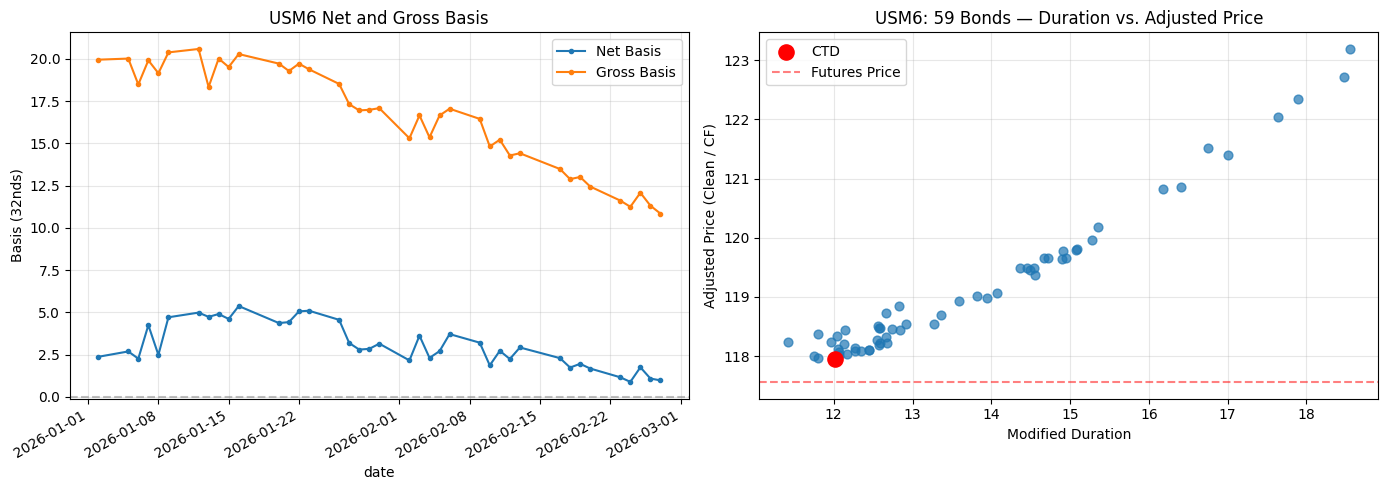

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily basis
ax1 = axes[0]
daily[['net_basis_32nds', 'gross_basis_32nds']].plot(ax=ax1, marker='o', markersize=3)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel('Basis (32nds)')
ax1.set_title('USM6 Net and Gross Basis')
ax1.legend(['Net Basis', 'Gross Basis'])
ax1.grid(True, alpha=0.3)

# Adjusted price vs duration
ax2 = axes[1]
ax2.scatter(overview['dur_adj_mid'], overview['adj_price'], s=40, zorder=5, alpha=0.7)
ctd_idx = overview['adj_price'].idxmin()
ax2.scatter(overview.loc[ctd_idx, 'dur_adj_mid'], overview.loc[ctd_idx, 'adj_price'],
           s=120, color='red', zorder=6, label='CTD')
ax2.axhline(FUT_PRICE, color='red', linestyle='--', alpha=0.5, label='Futures Price')
ax2.set_xlabel('Modified Duration')
ax2.set_ylabel('Adjusted Price (Clean / CF)')
ax2.set_title(f'USM6: {len(overview)} Bonds — Duration vs. Adjusted Price')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

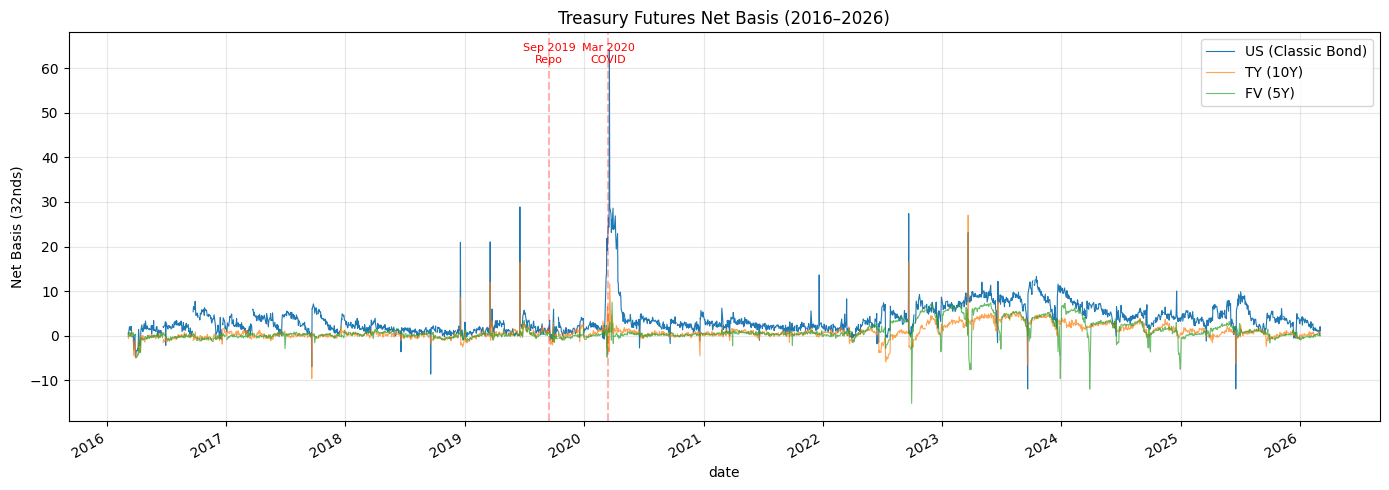

In [5]:
# Historical basis context
basis_net = pd.read_excel(DATA_DIR / 'treasury_basis.xlsx',
                          sheet_name='net_basis_32nds', index_col='date', parse_dates=True)

fig, ax = plt.subplots(figsize=(14, 5))
if 'US' in basis_net.columns:
    basis_net['US'].plot(ax=ax, linewidth=0.8, label='US (Classic Bond)')
if 'TY' in basis_net.columns:
    basis_net['TY'].plot(ax=ax, linewidth=0.8, alpha=0.7, label='TY (10Y)')
if 'FV' in basis_net.columns:
    basis_net['FV'].plot(ax=ax, linewidth=0.8, alpha=0.7, label='FV (5Y)')

for date_str, label in [('2019-09-17', 'Sep 2019\nRepo'), ('2020-03-15', 'Mar 2020\nCOVID')]:
    date = pd.Timestamp(date_str)
    if date >= basis_net.index.min():
        ax.axvline(date, color='red', alpha=0.3, linestyle='--')
        ax.annotate(label, xy=(date, ax.get_ylim()[1] * 0.9), fontsize=8,
                   ha='center', color='red')

ax.set_ylabel('Net Basis (32nds)')
ax.set_title('Treasury Futures Net Basis (2016–2026)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 5. Questions


### Question 1: Deliverable Basket and CTD Switching

**Analyze the USM6 deliverable basket and characterize how CTD identity depends on yield levels.**

a) For each of the 59 deliverable bonds, compute the adjusted clean price (clean price / conversion factor). Identify the current CTD. Report a table showing the top 15 bonds (sorted by adjusted price) with each bond's coupon, maturity, conversion factor, duration, and adjusted price.

*Note:* The top several bonds by adjusted price are very close together (within fractions of a 32nd). Your CTD may differ from the Bloomberg-reported CTD, which uses implied repo rate rather than adjusted price. A near-tie is expected at current yield levels — do not be concerned if your CTD differs from Bloomberg's.

b) Under parallel shifts of $\pm$300bp (in 5bp increments) to the GSW zero-coupon curve, reprice each bond by discounting its cash flows at the shifted spot rates and recompute adjusted prices. Plot two charts side-by-side:
   - All adjusted prices as a function of the yield shift (with the CTD envelope highlighted)
   - The CTD identity (which bond is cheapest) at each shift level

Since the GSW curve is a smooth parametric fit, model-implied prices at zero shift will not exactly match quoted market prices — this is expected.

c) Identify the **CTD switching points** — the yield shifts where the CTD transitions from one bond to another. How many distinct CTD bonds appear across the $\pm$300bp range? With 59 deliverables, do you observe more switching points than you would with a narrow basket? Relate the switching pattern to the bonds' durations and the conversion factor system (designed around a 6% notional yield).

d) At the current yield level (~4–4.5%), is the CTD a high-duration or low-duration bond? Explain why, referring to the convexity of the adjusted price curves and the conversion factor bias at yields below 6%.

Q1 valuation date used for shifted repricing: 2026-03-02
Q1 current CTD (market adjusted price): 912810TU Govt
Q1 model CTD at 0bp shift: 912810QS Govt
Distinct CTD bonds in +/-300bp range: 6
Number of switching points: 5
Validation checks: PASSED (shape + finite values).

Q1d quick classification:
Current CTD duration = 12.02, median basket duration = 12.84 -> low-duration.

Top 15 by current adjusted price:


,security_des,cpn,maturity,conversion,dur_adj_mid,px_last,adj_price
ticker,,,,,,,
912810TU Govt,T 4 3/8 08/15/43,4.3750,2043-08-15 00:00:00,0.8283,12.02,97.7031,117.9562
912810TW Govt,T 4 3/4 11/15/43,4.7500,2043-11-15 00:00:00,0.8667,11.80,102.2344,117.9582
912810TM Govt,T 4 11/15/42,4.0000,2042-11-15 00:00:00,0.7941,11.75,93.7031,117.9991
912810UB Govt,T 4 5/8 05/15/44,4.6250,2044-05-15 00:00:00,0.8510,12.07,100.4375,118.0229
912810TZ Govt,T 4 1/2 02/15/44,4.5000,2044-02-15 00:00:00,0.8388,12.17,99.0000,118.0258
912810TQ Govt,T 3 7/8 02/15/43,3.8750,2043-02-15 00:00:00,0.7794,12.07,92.0156,118.0596
912810RD Govt,T 3 3/4 11/15/43,3.7500,2043-11-15 00:00:00,0.7602,12.35,89.7656,118.0816
912810UF Govt,T 4 5/8 11/15/44,4.6250,2044-11-15 00:00:00,0.8487,12.27,100.2188,118.0850
912810RC Govt,T 3 5/8 08/15/43,3.6250,2043-08-15 00:00:00,0.7491,12.45,88.4688,118.1001



CTD switching points (Q1c):


,shift_from_bp,shift_to_bp,ctd_from,ctd_to
0,35,40,912810QS Govt,912810TW Govt
1,40,45,912810TW Govt,912810UF Govt
2,45,50,912810UF Govt,912810RQ Govt
3,50,55,912810RQ Govt,912810RT Govt
4,55,60,912810RT Govt,912810SN Govt


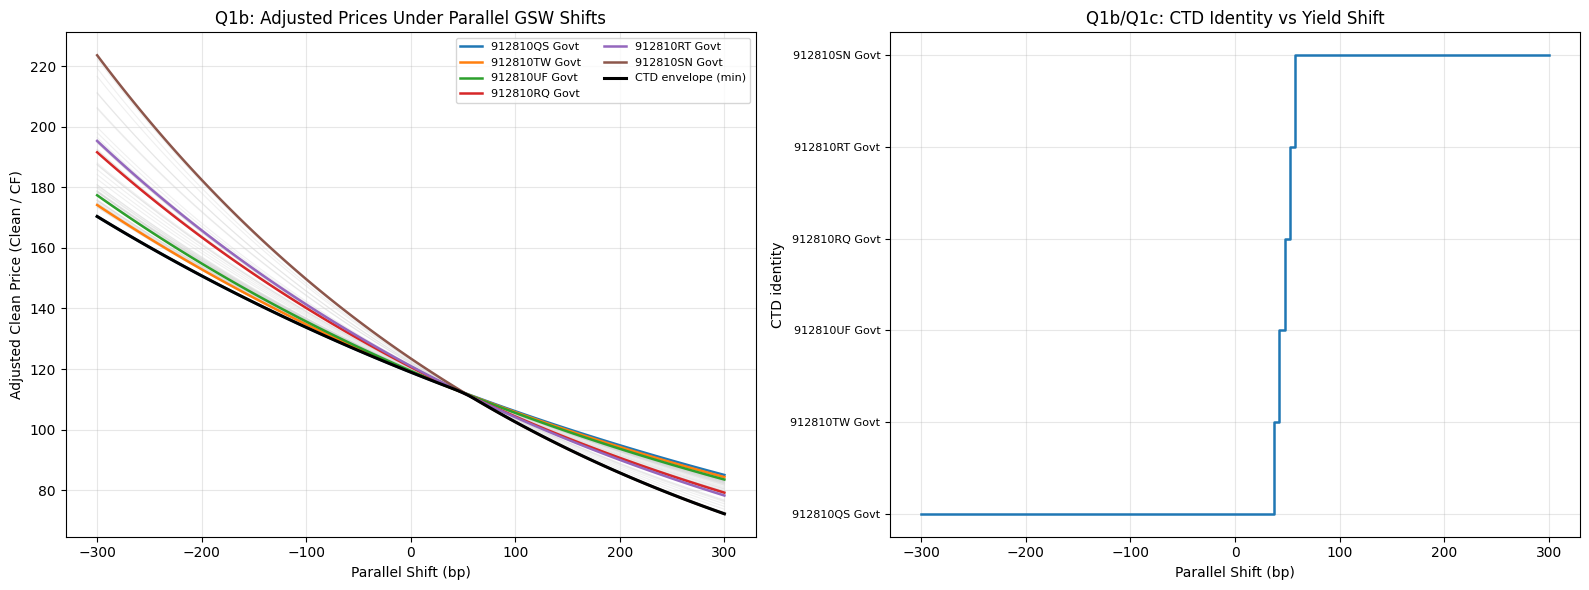

In [6]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Q1: CTD switching under parallel shifts to GSW spot curve
# =========================

FACE = 100.0


def _norm_coupon(cpn_val):
    """Convert coupon to decimal if needed (handles % or decimal input)."""
    cpn = float(cpn_val)
    return cpn / 100.0 if cpn > 1.0 else cpn


def _extract_svensson_params(df):
    """Extract beta0..beta3, tau1, tau2 from flexible sheet layouts."""
    params = {}

    # Layout A: columns ['parameter','value'] with rows BETA0..TAU2
    cols_lower = [str(c).strip().lower() for c in df.columns]
    if 'parameter' in cols_lower and 'value' in cols_lower:
        p_col = df.columns[cols_lower.index('parameter')]
        v_col = df.columns[cols_lower.index('value')]
        kv = {
            str(k).strip().lower(): float(v)
            for k, v in zip(df[p_col], df[v_col])
            if pd.notna(k) and pd.notna(v)
        }
        for k in ['beta0', 'beta1', 'beta2', 'beta3', 'tau1', 'tau2']:
            if k not in kv:
                raise ValueError(f"Could not parse Svensson params, missing: {k}")
            params[k] = kv[k]
        return params

    # Layout B: names in index, values in first column
    idx_map = {str(i).strip().lower(): i for i in df.index}
    if all(k in idx_map for k in ['beta0', 'beta1', 'beta2', 'beta3', 'tau1', 'tau2']):
        val_col = df.columns[0]
        for k in ['beta0', 'beta1', 'beta2', 'beta3', 'tau1', 'tau2']:
            params[k] = float(df.loc[idx_map[k], val_col])
        return params

    # Layout C: parameters are columns in first row
    row = df.iloc[0]
    norm_cols = {str(c).strip().lower().replace('_', '').replace('-', ''): c for c in df.columns}

    def _pick(*names):
        for n in names:
            key = n.lower().replace('_', '').replace('-', '')
            if key in norm_cols:
                return float(row[norm_cols[key]])
        return None

    params['beta0'] = _pick('beta0', 'b0')
    params['beta1'] = _pick('beta1', 'b1')
    params['beta2'] = _pick('beta2', 'b2')
    params['beta3'] = _pick('beta3', 'b3')
    params['tau1'] = _pick('tau1', 't1', 'lambda1')
    params['tau2'] = _pick('tau2', 't2', 'lambda2')

    missing = [k for k, v in params.items() if v is None]
    if missing:
        raise ValueError(f"Could not parse Svensson params, missing: {missing}")

    return params


def svensson_yield_pct(tau, p):
    """GSW Svensson zero yield in percent at maturity tau (years)."""
    tau = np.asarray(tau, dtype=float)
    x1 = tau / p['tau1']
    x2 = tau / p['tau2']

    with np.errstate(divide='ignore', invalid='ignore'):
        term1 = np.where(np.abs(x1) < 1e-12, 1.0, (1 - np.exp(-x1)) / x1)
        term2 = term1 - np.exp(-x1)
        term3 = np.where(np.abs(x2) < 1e-12, 1.0, (1 - np.exp(-x2)) / x2) - np.exp(-x2)

    return p['beta0'] + p['beta1'] * term1 + p['beta2'] * term2 + p['beta3'] * term3


def build_coupon_schedule(maturity_dt, value_dt):
    """Semiannual coupon dates after valuation date up to maturity, generated backward from maturity."""
    dates = []
    d = pd.Timestamp(maturity_dt)
    value_dt = pd.Timestamp(value_dt)
    while d > value_dt:
        dates.append(d)
        d = d - pd.DateOffset(months=6)
    dates.sort()
    return dates


def accrued_interest_at_valuation(cpn_dec, maturity_dt, value_dt, face=100.0):
    """Accrued interest on valuation date using semiannual coupon convention."""
    value_dt = pd.Timestamp(value_dt)
    d_next = pd.Timestamp(maturity_dt)
    while d_next > value_dt:
        d_prev = d_next - pd.DateOffset(months=6)
        if d_prev <= value_dt < d_next:
            frac = (value_dt - d_prev).days / (d_next - d_prev).days
            frac = max(0.0, min(1.0, frac))
            return face * cpn_dec / 2.0 * frac
        d_next = d_prev
    return 0.0


def clean_price_from_spot_curve(row, value_dt, shift_bp, sv_params, face=100.0):
    """Price one bond by discounting future cash flows at shifted GSW spot curve."""
    maturity = pd.Timestamp(row['maturity'])
    cpn_dec = _norm_coupon(row['cpn'])

    cpn_dates = build_coupon_schedule(maturity, value_dt)
    if len(cpn_dates) == 0:
        return np.nan

    t_years = np.array([(d - value_dt).days / 365.25 for d in cpn_dates], dtype=float)
    y_pct = svensson_yield_pct(t_years, sv_params) + (shift_bp / 100.0)  # bp -> percent
    disc = np.exp(-(y_pct / 100.0) * t_years)

    cashflows = np.full(len(cpn_dates), face * cpn_dec / 2.0)
    cashflows[-1] += face
    dirty = float(np.sum(cashflows * disc))

    ai = accrued_interest_at_valuation(cpn_dec, maturity, value_dt, face=face)
    return dirty - ai


# 1) Current CTD from market adjusted price (Q1a)
q1_adj_market = bonddata['px_last'] / bonddata['conversion']
q1_ctd_current = q1_adj_market.idxmin()
q1_top15 = (
    bonddata[['security_des', 'cpn', 'maturity', 'conversion', 'dur_adj_mid', 'px_last']]
    .assign(adj_price=q1_adj_market)
    .sort_values('adj_price')
    .head(15)
)

# 2) Load GSW Svensson parameters (Q1b)
gsw_file = sorted(DATA_DIR.glob('gsw_params_*.xlsx'))[-1]
sv_raw = pd.read_excel(gsw_file, sheet_name='svensson_params')
sv_params = _extract_svensson_params(sv_raw)

# Use file snapshot date as valuation date (fallback: today if date not in filename)
date_match = re.search(r'(\d{4}-\d{2}-\d{2})', usm6_file.name)
q1_value_date = pd.Timestamp(date_match.group(1)) if date_match else pd.Timestamp.today().normalize()

# 3) Reprice all bonds under parallel shifts +/-300bp in 5bp steps (Q1b)
q1_shifts_bp = np.arange(-300, 301, 5)
bond_ids = bonddata.index.to_numpy()
n_shifts = len(q1_shifts_bp)
n_bonds = len(bond_ids)

q1_adj_price_by_shift = np.full((n_shifts, n_bonds), np.nan)

for s_idx, shift_bp in enumerate(q1_shifts_bp):
    for j, b in enumerate(bond_ids):
        clean_px = clean_price_from_spot_curve(
            bonddata.loc[b], q1_value_date, shift_bp, sv_params, face=FACE
        )
        q1_adj_price_by_shift[s_idx, j] = clean_px / float(bonddata.loc[b, 'conversion'])

# 4) CTD identity path and switching points (Q1c)
q1_ctd_idx_by_shift = np.argmin(q1_adj_price_by_shift, axis=1)
q1_ctd_by_shift = bond_ids[q1_ctd_idx_by_shift]
q1_ctd_envelope = np.min(q1_adj_price_by_shift, axis=1)

switch_locs = np.where(q1_ctd_by_shift[1:] != q1_ctd_by_shift[:-1])[0]
q1_switch_points = []
for loc in switch_locs:
    q1_switch_points.append({
        'shift_from_bp': int(q1_shifts_bp[loc]),
        'shift_to_bp': int(q1_shifts_bp[loc + 1]),
        'ctd_from': str(q1_ctd_by_shift[loc]),
        'ctd_to': str(q1_ctd_by_shift[loc + 1]),
    })
q1_switch_df = pd.DataFrame(q1_switch_points)
q1_distinct_ctd = pd.Index(q1_ctd_by_shift).unique().tolist()

# 5) Plot adjusted-price curves + CTD identity (Q1b)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for j in range(n_bonds):
    ax.plot(q1_shifts_bp, q1_adj_price_by_shift[:, j], color='lightgray', alpha=0.35, linewidth=0.8)

# Highlight bonds that are CTD at least once
ctd_once = pd.Index(q1_ctd_by_shift).unique()
for b in ctd_once:
    j = np.where(bond_ids == b)[0][0]
    ax.plot(q1_shifts_bp, q1_adj_price_by_shift[:, j], linewidth=1.8, label=str(b))

ax.plot(q1_shifts_bp, q1_ctd_envelope, color='black', linewidth=2.2, label='CTD envelope (min)')
ax.set_xlabel('Parallel Shift (bp)')
ax.set_ylabel('Adjusted Clean Price (Clean / CF)')
ax.set_title('Q1b: Adjusted Prices Under Parallel GSW Shifts')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=8, ncol=2)

ax = axes[1]
ctd_once_list = list(ctd_once)
ctd_to_code = {b: i for i, b in enumerate(ctd_once_list)}
q1_ctd_code_series = np.array([ctd_to_code[b] for b in q1_ctd_by_shift])
ax.step(q1_shifts_bp, q1_ctd_code_series, where='mid', linewidth=1.8)
ax.set_xlabel('Parallel Shift (bp)')
ax.set_ylabel('CTD identity')
ax.set_title('Q1b/Q1c: CTD Identity vs Yield Shift')
ax.set_yticks(np.arange(len(ctd_once_list)))
ax.set_yticklabels(ctd_once_list, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# 6) Validation checks and outputs needed downstream
assert q1_adj_price_by_shift.shape == (len(q1_shifts_bp), len(bonddata)), 'Unexpected matrix shape.'
assert np.isfinite(q1_adj_price_by_shift).all(), 'Non-finite adjusted prices found.'

q1_model_ctd_0bp = q1_ctd_by_shift[np.where(q1_shifts_bp == 0)[0][0]]
q1_current_ctd_duration = float(bonddata.loc[q1_ctd_current, 'dur_adj_mid'])
q1_duration_median = float(bonddata['dur_adj_mid'].median())
q1_duration_bucket = 'high-duration' if q1_current_ctd_duration >= q1_duration_median else 'low-duration'

print(f'Q1 valuation date used for shifted repricing: {q1_value_date.date()}')
print(f'Q1 current CTD (market adjusted price): {q1_ctd_current}')
print(f'Q1 model CTD at 0bp shift: {q1_model_ctd_0bp}')
print(f'Distinct CTD bonds in +/-300bp range: {len(q1_distinct_ctd)}')
print(f'Number of switching points: {len(q1_switch_df)}')
print('Validation checks: PASSED (shape + finite values).')

print('\nQ1d quick classification:')
print(
    f'Current CTD duration = {q1_current_ctd_duration:.2f}, '
    f'median basket duration = {q1_duration_median:.2f} -> {q1_duration_bucket}.'
)

print('\nTop 15 by current adjusted price:')
display(q1_top15.style.format({
    'cpn': '{:.4f}',
    'conversion': '{:.4f}',
    'dur_adj_mid': '{:.2f}',
    'px_last': '{:.4f}',
    'adj_price': '{:.4f}'
}))

print('\nCTD switching points (Q1c):')
display(q1_switch_df if not q1_switch_df.empty else pd.DataFrame({'info': ['No switching points found']}))

### Question 2: Rate Tree Construction and Calibration

**Calibrate a weekly BDT tree to the GSW Treasury zero-coupon curve and verify the calibration.**

The tree must extend from today to the longest bond maturity (~25Y from delivery) so that every bond's coupon cash flows can be backward-inducted. Weekly time steps (dt = 1/52) keep the tree manageable (~1300 steps, ~16 steps to delivery, 17 terminal states at delivery).

a) Load the GSW Svensson parameters from `gsw_params_2026-02-27.xlsx`. The Svensson formula gives continuously compounded zero-coupon yields at any maturity $\tau$:

$$y(\tau) = \beta_0 + \beta_1 \frac{1 - e^{-\tau/\tau_1}}{\tau/\tau_1} + \beta_2 \left[\frac{1 - e^{-\tau/\tau_1}}{\tau/\tau_1} - e^{-\tau/\tau_1}\right] + \beta_3 \left[\frac{1 - e^{-\tau/\tau_2}}{\tau/\tau_2} - e^{-\tau/\tau_2}\right]$$

Evaluate this at weekly tenors from $1/52$ to the longest bond maturity. Note that the Svensson formula outputs yields in **percent** (e.g. 4.5 means 4.5%); convert to decimals before computing discount factors: $D(\tau) = e^{-y(\tau)/100 \cdot \tau}$. Plot the GSW zero-coupon yield curve and the corresponding discount factors.

For volatility, load the cap curves data and use the flat vol at the ~0.5Y tenor (~11.1%) as a constant. Calibrate the weekly BDT tree using `calibrate_bdt` from `bdt_numpy`. Report the tree dimensions (number of steps, number of states at delivery) and calibration time.

b) **Verification:** Reprice zero-coupon bonds at each weekly tenor using the Arrow-Debreu state prices returned by `calibrate_bdt`. The AD calibration is exact by construction — pricing errors should be at machine precision (< 1e-12). Report the maximum absolute error.

c) Display the rate tree at the delivery horizon (first 17 columns) as a heatmap. Plot a histogram of the 17 terminal short rates at the delivery step. Report the range (min to max terminal rate).

d) The 17 terminal states represent the range of rate outcomes the tree considers at delivery. Do the bond prices at these terminal states span enough of the adjusted-price surface to capture the key CTD switching transitions you identified in Q1? Note that the terminal short rates and the Q1 bond YTMs are different quantities (short-term vs. long-term rates), so focus your comparison on whether the tree produces meaningful CTD switching — not on a direct rate-to-rate comparison.

In [25]:
import time
from bdt_numpy import calibrate_bdt

# =========================
# Q2 (minimal for Q3/Q4): weekly BDT calibration + reusable inputs
# =========================

# 1) Time grid and bond arrays used in Q3/Q4
q2_dt = 1.0 / 52.0
q2_value_date = pd.Timestamp(usm6_file.stem.split('_')[-1])
q2_delivery_date = pd.to_datetime(futdata.loc['last_tradeable_dt'].values[0])

# Use ceil so delivery horizon is not truncated when weeks are fractional
q2_n_delivery = max(1, int(np.ceil((q2_delivery_date - q2_value_date).days / 7.0)))

q3_cpn_arr = bonddata['cpn'].astype(float).to_numpy()
q3_cpn_arr = np.where(q3_cpn_arr > 1.0, q3_cpn_arr / 100.0, q3_cpn_arr)
q3_cf_arr = bonddata['conversion'].astype(float).to_numpy()
q3_T_rem_arr = ((pd.to_datetime(bonddata['maturity']) - q2_delivery_date).dt.days / 365.25).to_numpy(dtype=float)

# Tree length must cover today -> longest bond maturity
q2_max_horizon_years = (pd.to_datetime(bonddata['maturity']).max() - q2_value_date).days / 365.25
q2_n_steps = int(np.ceil(q2_max_horizon_years / q2_dt))
q2_tenors = np.arange(1, q2_n_steps + 1) * q2_dt

# 2) Build weekly discount curve from GSW Svensson parameters
q2_gsw_file = sorted(DATA_DIR.glob('gsw_params_*.xlsx'))[-1]
q2_sv = pd.read_excel(q2_gsw_file, sheet_name='svensson_params')
q2_sv.columns = [str(c).strip().lower() for c in q2_sv.columns]

if not {'parameter', 'value'}.issubset(set(q2_sv.columns)):
    raise ValueError('svensson_params sheet must contain columns: parameter, value')

q2_sv_map = dict(zip(q2_sv['parameter'].str.strip().str.lower(), q2_sv['value'].astype(float)))
q2_sv_params = {k: q2_sv_map[k] for k in ['beta0', 'beta1', 'beta2', 'beta3', 'tau1', 'tau2']}

x1 = q2_tenors / q2_sv_params['tau1']
x2 = q2_tenors / q2_sv_params['tau2']
term1 = np.where(np.abs(x1) < 1e-12, 1.0, (1 - np.exp(-x1)) / x1)
term2 = term1 - np.exp(-x1)
term3 = np.where(np.abs(x2) < 1e-12, 1.0, (1 - np.exp(-x2)) / x2) - np.exp(-x2)

q2_zero_yield_pct = (
    q2_sv_params['beta0']
    + q2_sv_params['beta1'] * term1
    + q2_sv_params['beta2'] * term2
    + q2_sv_params['beta3'] * term3
)
q2_discounts_base = np.exp(-(q2_zero_yield_pct / 100.0) * q2_tenors)

# Used by Q4b: parallel shifts to spot curve before discount construction
def q2_discounts_shifted(shift_bp):
    y_shifted_pct = q2_zero_yield_pct + (shift_bp / 100.0)
    return np.exp(-(y_shifted_pct / 100.0) * q2_tenors)

# 3) Flat vol from cap curve near 0.5Y
q2_cap_file = sorted(DATA_DIR.glob('cap_curves_*.xlsx'))[-1]
q2_cap = pd.read_excel(q2_cap_file, sheet_name=0)
q2_cap.columns = [str(c).strip().lower() for c in q2_cap.columns]

tenor_col = next((c for c in ['tenor', 'maturity', 'term', 'years'] if c in q2_cap.columns), q2_cap.columns[0])
vol_col = next((c for c in q2_cap.columns if ('flat' in c and 'vol' in c)), None)
if vol_col is None:
    vol_col = next((c for c in q2_cap.columns if 'vol' in c), None)
if vol_col is None:
    raise ValueError('Could not find volatility column in cap curve file.')

q2_cap_tmp = q2_cap[[tenor_col, vol_col]].apply(pd.to_numeric, errors='coerce').dropna()
q2_sigma_base = float(q2_cap_tmp.iloc[(q2_cap_tmp[tenor_col] - 0.5).abs().argmin()][vol_col])
q2_sigma_base = q2_sigma_base / 100.0 if q2_sigma_base > 1.0 else q2_sigma_base

# 4) Calibrate weekly BDT tree
_t0 = time.perf_counter()
q2_rate_tree_base, q2_z_top_base, q2_ad_prices_base = calibrate_bdt(
    q2_discounts_base, sigma=q2_sigma_base, dt=q2_dt
)
q2_calib_sec = time.perf_counter() - _t0

# 5) Compact verification (exact AD calibration check)
# Maturity m*dt for m=1..n-1 from AD column sums
q2_model_discounts = np.array([
    np.nansum(q2_ad_prices_base[:m + 1, m])
    for m in range(1, len(q2_discounts_base))
])
# Final maturity n*dt from one-step discount of column n-1 state prices
m_last = len(q2_discounts_base) - 1
q2_d_last = np.nansum(
    q2_ad_prices_base[:m_last + 1, m_last]
    * np.exp(-q2_rate_tree_base[:m_last + 1, m_last] * q2_dt)
)
q2_model_discounts = np.append(q2_model_discounts, q2_d_last)
q2_ad_max_abs_err = float(np.max(np.abs(q2_model_discounts - q2_discounts_base)))

q2_terminal_rates = q2_rate_tree_base[:q2_n_delivery + 1, q2_n_delivery]

print('Q2 core outputs ready for Q3/Q4:')
print(f'- dt = {q2_dt:.8f}')
print(f'- valuation date = {q2_value_date.date()}, delivery date = {q2_delivery_date.date()}')
print(f'- n_delivery = {q2_n_delivery} weeks -> terminal states = {q2_n_delivery + 1}')
print(f'- tree steps = {q2_n_steps}, rate_tree shape = {q2_rate_tree_base.shape}')
print(f'- sigma_base (flat vol near 0.5Y) = {q2_sigma_base:.6f}')
print(f'- calibration time = {q2_calib_sec:.3f}s')
print(f'- AD max abs error = {q2_ad_max_abs_err:.3e}')
print(f'- delivery-step short-rate range = [{q2_terminal_rates.min():.4%}, {q2_terminal_rates.max():.4%}]')
print(f'- bond arrays lengths: cpn={len(q3_cpn_arr)}, T_rem={len(q3_T_rem_arr)}, cf={len(q3_cf_arr)}')

Q2 core outputs ready for Q3/Q4:
- dt = 0.01923077
- valuation date = 2026-03-02, delivery date = 2026-06-18
- n_delivery = 16 weeks -> terminal states = 17
- tree steps = 1311, rate_tree shape = (1312, 1312)
- sigma_base (flat vol near 0.5Y) = 0.111096
- calibration time = 1.950s
- AD max abs error = 2.220e-16
- delivery-step short-rate range = [2.7742%, 4.5420%]
- bond arrays lengths: cpn=59, T_rem=59, cf=59


### Question 3: Delivery Option Valuation

**Price the delivery option using full backward induction through the tree and compare to the market basis.**

Each bond's coupon cash flows are backward-inducted from maturity through the rate tree to delivery. At each tree node, the one-period discount factor uses the node's short rate: $d_{i,k} = e^{-r_{i,k} \cdot dt}$. This correctly incorporates the model-implied term structure at every node — no flat-yield approximation is needed.

a) Using `futures_delivery_option_tree` from `bdt_numpy`, price all 59 deliverable bonds at each of the 17 terminal states. This function backward-inducts each bond from maturity to delivery, computes the (17 $\times$ 59) adjusted price matrix, identifies the CTD at each state, and backward-inducts the futures price. Display the adjusted price matrix for the bonds that are CTD in at least one state as a heatmap.


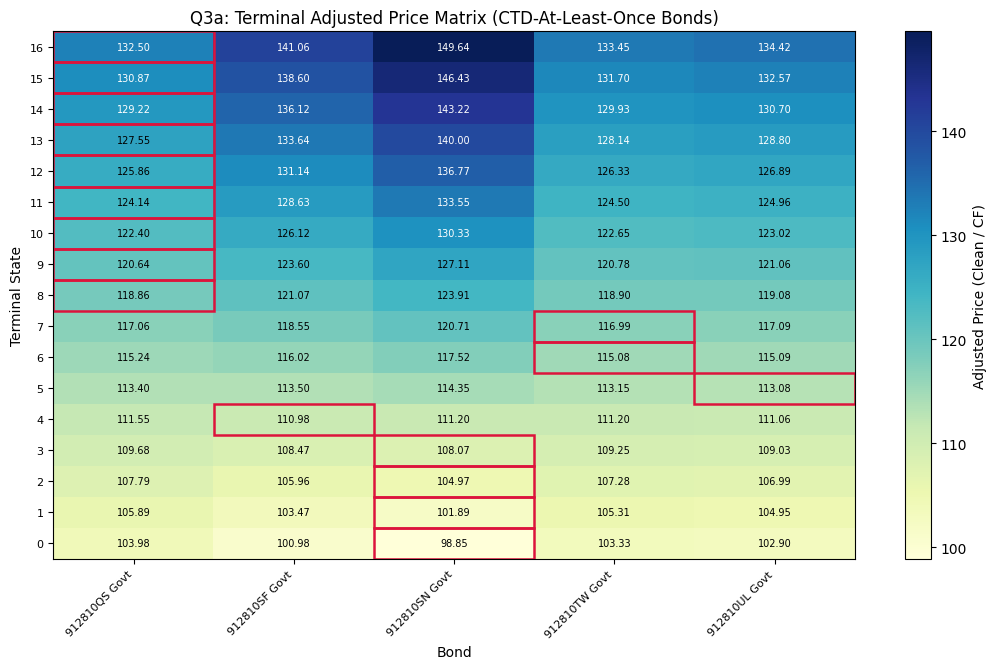

In [17]:
from matplotlib import colors
from matplotlib.patches import Rectangle
from bdt_numpy import futures_delivery_option_tree

required_vars = [
    'q2_rate_tree_base', 'q3_cpn_arr', 'q3_T_rem_arr', 'q3_cf_arr', 'q2_n_delivery', 'q2_dt', 'bonddata'
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required inputs: {missing}. Please run the Q2 code cell first.')

# Q3a: price all deliverables at terminal states via full tree backward induction
q3a_result = futures_delivery_option_tree(
    rate_tree=q2_rate_tree_base,
    cpn_arr=q3_cpn_arr,
    T_rem_arr=q3_T_rem_arr,
    cf_arr=q3_cf_arr,
    n_delivery=q2_n_delivery,
    dt=q2_dt,
)

q3a_adj_all = q3a_result['terminal_adj_prices']
q3a_ctd_by_state = q3a_result['ctd_by_state']
q3a_terminal_rates = q3a_result['terminal_rates']

# Keep only bonds that are CTD in at least one terminal state
q3a_ctd_unique_idx = np.unique(q3a_ctd_by_state)
q3a_ctd_bond_labels = bonddata.index.to_numpy()[q3a_ctd_unique_idx]
q3a_adj_ctd_only = q3a_adj_all[:, q3a_ctd_unique_idx]

# Map full-basket bond index -> displayed heatmap column index
q3a_col_map = {int(b_idx): col for col, b_idx in enumerate(q3a_ctd_unique_idx)}

# Heatmap of adjusted price matrix for CTD-at-least-once bonds with in-cell labels
fig, ax = plt.subplots(figsize=(1.35 * q3a_adj_ctd_only.shape[1] + 4, 6.8))
im = ax.imshow(q3a_adj_ctd_only, aspect='auto', origin='lower', cmap='YlGnBu')

ax.set_title('Q3a: Terminal Adjusted Price Matrix (CTD-At-Least-Once Bonds)')
ax.set_xlabel('Bond')
ax.set_ylabel('Terminal State')
ax.set_xticks(np.arange(len(q3a_ctd_bond_labels)))
ax.set_xticklabels(q3a_ctd_bond_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(np.arange(q3a_adj_ctd_only.shape[0]))
ax.set_yticklabels([str(i) for i in range(q3a_adj_ctd_only.shape[0])], fontsize=8)

# Annotate each cell with contrast-aware text color based on background luminance
norm = colors.Normalize(vmin=float(np.nanmin(q3a_adj_ctd_only)), vmax=float(np.nanmax(q3a_adj_ctd_only)))
cmap = im.get_cmap()
for i in range(q3a_adj_ctd_only.shape[0]):
    for j in range(q3a_adj_ctd_only.shape[1]):
        val = q3a_adj_ctd_only[i, j]
        r, g, b, _ = cmap(norm(val))
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        txt_color = 'black' if luminance > 0.55 else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=7)

# Highlight the CTD cell in each state with a colored border
for state_i, full_bond_idx in enumerate(q3a_ctd_by_state):
    col_j = q3a_col_map[int(full_bond_idx)]
    rect = Rectangle((col_j - 0.5, state_i - 0.5), 1, 1,
                     fill=False, edgecolor='crimson', linewidth=1.8)
    ax.add_patch(rect)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Adjusted Price (Clean / CF)')
plt.tight_layout()


b) Plot the CTD identity vs. terminal short rate. How does the switching pattern compare to the parallel-shift analysis from Q1? With the wide USM6 basket, how many distinct bonds become CTD?


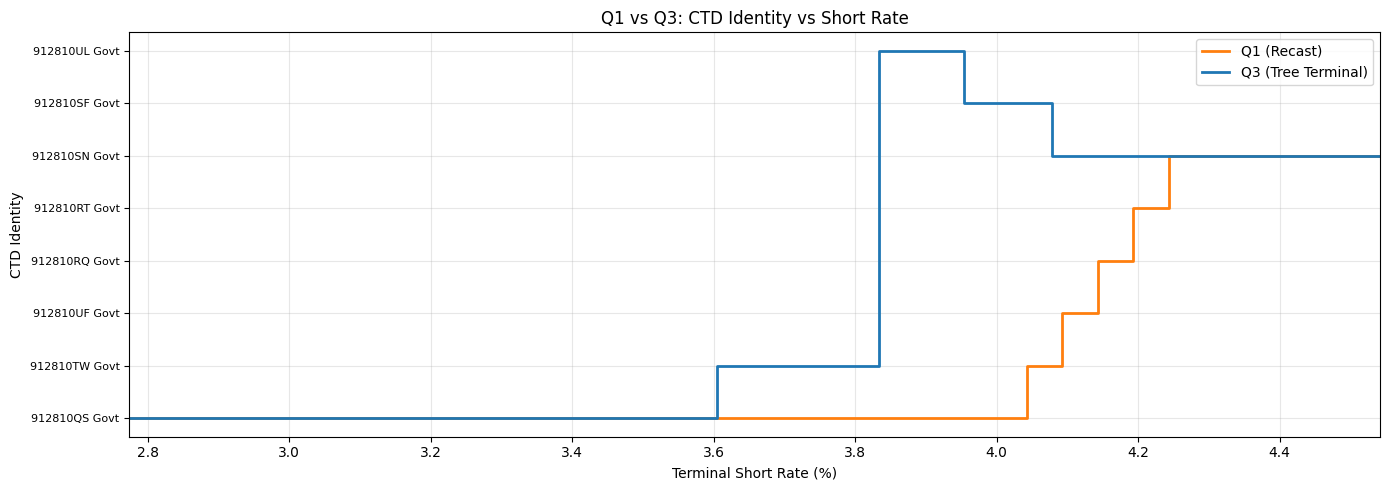

In [26]:
# Q3b: merged comparison plot (Q1 recast + Q3 on one chart)

required_vars = [
    'q3a_result', 'bonddata', 'q1_ctd_by_shift', 'q1_shifts_bp', 'q2_n_delivery', 'q2_dt', 'q2_sv_params'
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required inputs: {missing}. Please run Q1/Q2/Q3a cells first.')

# ---------- Build CTD label series ----------
q3_rates_pct = q3a_result['terminal_rates'] * 100.0
q3_labels = bonddata.index.to_numpy()[q3a_result['ctd_by_state']]

tau_del = q2_n_delivery * q2_dt
x1 = tau_del / q2_sv_params['tau1']
x2 = tau_del / q2_sv_params['tau2']
term1 = (1 - np.exp(-x1)) / x1 if abs(x1) > 1e-12 else 1.0
term2 = term1 - np.exp(-x1)
term3 = ((1 - np.exp(-x2)) / x2 - np.exp(-x2)) if abs(x2) > 1e-12 else 1.0

q1_base_short_rate_pct = (
    q2_sv_params['beta0']
    + q2_sv_params['beta1'] * term1
    + q2_sv_params['beta2'] * term2
    + q2_sv_params['beta3'] * term3
)
q1_rates_pct = q1_base_short_rate_pct + (q1_shifts_bp / 100.0)
q1_labels = np.asarray(q1_ctd_by_shift)

# Use full Q1 label set as baseline, then expand with any Q3-only labels
q1_unique_labels = pd.Index(q1_labels).unique().tolist()
all_labels = list(q1_unique_labels)
label_set = set(all_labels)
for label in pd.Index(q3_labels).unique().tolist():
    if label not in label_set:
        all_labels.append(label)
        label_set.add(label)

label_to_code = {label: i for i, label in enumerate(all_labels)}
q1_codes = np.array([label_to_code[label] for label in q1_labels])
q3_codes = np.array([label_to_code[label] for label in q3_labels])

ord1 = np.argsort(q1_rates_pct)
x_q1 = q1_rates_pct[ord1]
y_q1 = q1_codes[ord1]

ord3 = np.argsort(q3_rates_pct)
x_q3 = q3_rates_pct[ord3]
y_q3 = q3_codes[ord3]

# ---------- One merged plot ----------
fig, ax = plt.subplots(figsize=(14, 5))
ax.step(x_q1, y_q1, where='mid', linewidth=2.0, color='tab:orange', label='Q1 (Recast)')
ax.step(x_q3, y_q3, where='mid', linewidth=2.0, color='tab:blue', label='Q3 (Tree Terminal)')

ax.set_title('Q1 vs Q3: CTD Identity vs Short Rate')
ax.set_xlabel('Terminal Short Rate (%)')
ax.set_ylabel('CTD Identity')
ax.set_yticks(np.arange(len(all_labels)))
ax.set_yticklabels(all_labels, fontsize=8)
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

# Keep x-range focused on Q3 terminal-rate region for direct comparison
x_min, x_max = float(np.min(x_q3)), float(np.max(x_q3))
ax.set_xlim(x_min, x_max)

plt.tight_layout()

The two approaches agree on the same CTD when rate changes are large, but they diverge in the small-movement region, suggesting that CTD determination is complex, and the parallel-shift analysis and the BDT tree do not produce consistent predictions across all rate scenarios.

Within the USM6 deliverable basket, a total of eight distinct bonds become CTD.


c) Report the tree-implied futures price, the no-switching price (using the CTD at terminal state 8, i.e. the middle of the 17 states indexed 0–16), and the delivery option value in 32nds:

$$V_{\text{option}} = F_{\text{no-switch}} - F_{\text{tree}}$$

Compare to the observed net basis from the Bloomberg data. Is the model option value of the right magnitude?


In [30]:
# Q3c: required outputs only (observed net basis uses latest available)
required_vars = [
    'q3a_result', 'daily', 'bonddata', 'q2_n_delivery'
 ]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required inputs: {missing}. Please run Q1/Q2/Q3a cells first.')

# Tree-implied futures and delivery option metrics from Q3a full-tree result
q3c_futures_tree = float(q3a_result['futures_price'])
q3c_futures_no_switch = float(q3a_result['futures_no_switch'])
q3c_option_32 = float(q3a_result['option_value_32'])

# Median terminal state for 17 states is 8 (0..16)
q3c_state_mid = int((q2_n_delivery + 1) // 2)
q3c_fixed_ctd_idx = int(q3a_result.get('fixed_ctd_idx', q3a_result['ctd_by_state'][q3c_state_mid]))
q3c_fixed_ctd_label = str(bonddata.index.to_numpy()[q3c_fixed_ctd_idx])

# Observed net basis (32nds): latest non-NaN from daily sheet
if 'net_basis_32nds' not in daily.columns:
    raise RuntimeError("daily sheet missing 'net_basis_32nds' column")

q3c_series = pd.to_numeric(daily['net_basis_32nds'], errors='coerce').dropna()
if q3c_series.empty:
    raise RuntimeError("No valid non-NaN 'net_basis_32nds' values found in daily sheet")

q3c_obs_date = pd.Timestamp(q3c_series.index[-1]).date()
q3c_obs_net_basis_32 = float(q3c_series.iloc[-1])
q3c_obs_source = f"daily sheet (latest: {q3c_obs_date})"

print(f'Tree-implied futures price: {q3c_futures_tree:.6f}')
print(f'No-switching price (state {q3c_state_mid} CTD = {q3c_fixed_ctd_label}): {q3c_futures_no_switch:.6f}')
print(f'Delivery option value (32nds): {q3c_option_32:.6f}')
print(f'Observed net basis (32nds) [{q3c_obs_source}]: {q3c_obs_net_basis_32:.6f}')

Tree-implied futures price: 118.733380
No-switching price (state 8 CTD = 912810QS Govt): 118.822950
Delivery option value (32nds): 2.866237
Observed net basis (32nds) [daily sheet (latest: 2026-02-27)]: 0.972800


The option value is of the same order of magnitude as the observed net basis, but it is materially larger, approximately three times than the net basiss.


d) Discuss the model's pricing accuracy: how close is the tree-implied futures price to the Bloomberg market price? What factors might explain any discrepancy (the gap between the GSW curve date and the market data date, other embedded options, repo/financing effects)?

In [31]:
# Q4d: compare two prices (no plot for single-point comparison)
required_vars = ['q3a_result', 'FUT_PRICE']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required inputs: {missing}. Please run Q3a and data-loading cells first.')

q4d_model_futures_price = float(q3a_result['futures_price'])
q4d_market_futures_price = float(FUT_PRICE)

print(f'Model futures price (tree-implied): {q4d_model_futures_price:.6f}')
print(f'Market futures price (Bloomberg): {q4d_market_futures_price:.6f}')

Model futures price (tree-implied): 118.733380
Market futures price (Bloomberg): 117.562500


In [ ]:
required_vars = ['q3a_result', 'q2_n_delivery', 'FUT_PRICE']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required inputs: {missing}. Please run Q2/Q3a/data cells first.')

# Terminal payoff for futures = min adjusted price across deliverables at each terminal state
q4d_terminal_payoff = np.min(q3a_result['terminal_adj_prices'], axis=1)
q4d_tree_price = float(q3a_result['futures_price'])
q4d_market_price = float(FUT_PRICE)

# Monte Carlo on the terminal state distribution implied by the binomial tree
q4d_n_paths = 200000
q4d_rng = np.random.default_rng(42)
q4d_state_idx = q4d_rng.binomial(n=q2_n_delivery, p=0.5, size=q4d_n_paths)
q4d_mc_payoff = q4d_terminal_payoff[q4d_state_idx]
q4d_mc_price = float(np.mean(q4d_mc_payoff))
q4d_mc_std_err = float(np.std(q4d_mc_payoff, ddof=1) / np.sqrt(q4d_n_paths))

q4d_compare = pd.DataFrame({
    'method': ['Tree-implied', 'Monte Carlo', 'Market (Bloomberg)'],
    'futures_price': [q4d_tree_price, q4d_mc_price, q4d_market_price]
})

display(q4d_compare)
print(f'Monte Carlo standard error: {q4d_mc_std_err:.6f}')

,method,futures_price
0,Tree-implied,118.733380
1,Monte Carlo,118.734445
2,Market (Bloomberg),117.562500


Monte Carlo standard error: 0.008347


The tree model overprices the futures by about 1.17 points. The near-identical Monte Carlo estimate (118.734) does not make the model closer to the market, but it does confirm that the tree result is numerically robust within the same modeling framework. Overall the difference is small.

First, the GSW curve used to calibrate the tree is from February 27, while the Bloomberg futures price and bond data are from March 2. If yields changed during those days, the discount curve in the model would not fully reflect the market conditions when the futures price was observed.

Second, the model only captures the quality option but ignores other embedded delivery options, including the timing option, end-of-month option, and wildcard option. These options give the short additional flexibility in choosing when and how to deliver, increasing the value of the delivery option. Ignoring them therefore tends to make the model overprice the futures.

Third, some CTD bonds may be financed at unusually low repo rates due to liquidity and high demand. This reduces the cost of holding the bond until delivery and can lower the equilibrium futures price. 

### Question 4: Sensitivity Analysis

**Examine how the delivery option value depends on volatility, yield level, and time to delivery.**

Each sensitivity requires recalibrating the tree and re-running `futures_delivery_option_tree`. With weekly steps, the calibration + pricing cycle takes a few seconds per scenario — dense sweeps are feasible.

a) **Volatility:** Scale the flat vol by multipliers of 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, and 3.0. For each, recalibrate the tree and recompute the delivery option value. Plot option value (32nds) vs. volatility multiplier. Explain the shape: why does higher vol increase option value?


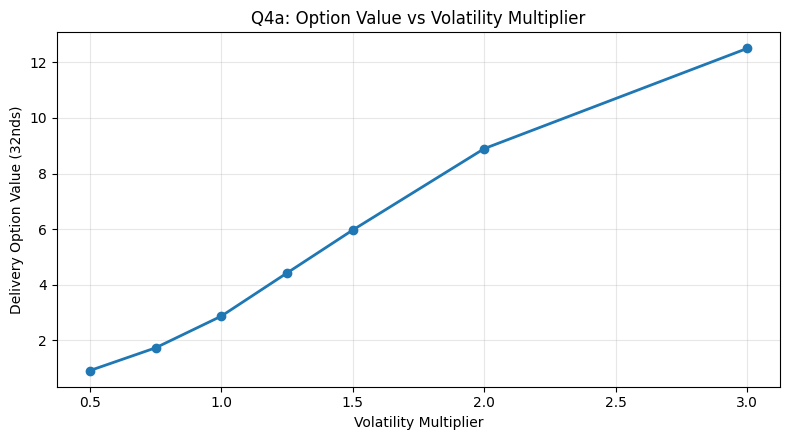

In [35]:
# Q4a: volatility sensitivity (plot only)
required_vars = [
    'q2_discounts_base', 'q2_sigma_base', 'q2_dt', 'q2_n_delivery',
    'q3_cpn_arr', 'q3_T_rem_arr', 'q3_cf_arr'
 ]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required inputs: {missing}. Please run Q2/Q3 setup cells first.')

from bdt_numpy import calibrate_bdt, futures_delivery_option_tree

q4a_vol_mult = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0], dtype=float)
q4a_option_32 = []

for m in q4a_vol_mult:
    rt_m, _, _ = calibrate_bdt(
        q2_discounts_base, sigma=float(q2_sigma_base * m), dt=q2_dt
    )
    res_m = futures_delivery_option_tree(
        rt_m, q3_cpn_arr, q3_T_rem_arr, q3_cf_arr, n_delivery=q2_n_delivery, dt=q2_dt
    )
    q4a_option_32.append(float(res_m['option_value_32']))

q4a_option_32 = np.array(q4a_option_32, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(q4a_vol_mult, q4a_option_32, marker='o', linewidth=2, color='tab:blue')
ax.set_xlabel('Volatility Multiplier')
ax.set_ylabel('Delivery Option Value (32nds)')
ax.set_title('Q4a: Option Value vs Volatility Multiplier')
ax.grid(alpha=0.3)
plt.tight_layout()

Higher volatility increases the delivery option value for two reasons. Intuitively, greater volatility means more uncertainty about future interest rates, which increases the value of having the flexibility to choose the cheapest bond to deliver. In the BDT tree, higher volatility also makes the short-rate tree more dispersed, creating larger differences between high- and low-rate states. Greater dispersion increases the likelihood of CTD switching across states, raising the expected payoff from the delivery option.


b) **Yield level:** Apply parallel shifts of +-200bp (in 25bp increments) to the GSW zero-coupon curve before computing discount factors. Recalibrate the tree at each shift and recompute the option value. Plot option value vs. yield shift. Is the option value highest near the CTD switching points you identified in Q1?


Highest option value: 18.339796 (32nds) at shift 75 bp


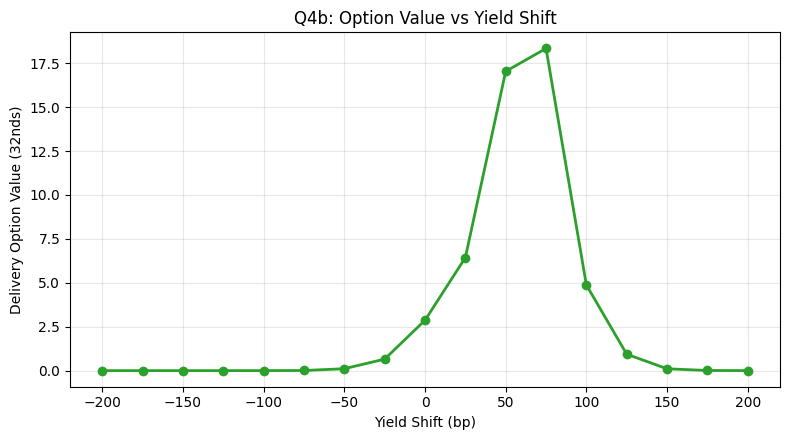

In [37]:
# Q4b: yield-level sensitivity (plot only)
required_vars = [
    'q2_discounts_shifted', 'q2_sigma_base', 'q2_dt', 'q2_n_delivery',
    'q3_cpn_arr', 'q3_T_rem_arr', 'q3_cf_arr'
 ]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required inputs: {missing}. Please run Q2/Q3 setup cells first.')

from bdt_numpy import calibrate_bdt, futures_delivery_option_tree

q4b_shift_bp = np.arange(-200, 201, 25, dtype=float)
q4b_option_32 = []

for s in q4b_shift_bp:
    d_shift = q2_discounts_shifted(float(s))
    rt_s, _, _ = calibrate_bdt(d_shift, sigma=float(q2_sigma_base), dt=q2_dt)
    res_s = futures_delivery_option_tree(
        rt_s, q3_cpn_arr, q3_T_rem_arr, q3_cf_arr, n_delivery=q2_n_delivery, dt=q2_dt
    )
    q4b_option_32.append(float(res_s['option_value_32']))

q4b_option_32 = np.array(q4b_option_32, dtype=float)
print(f"Highest option value: {q4b_option_32.max():.6f} (32nds) at shift {q4b_shift_bp[np.argmax(q4b_option_32)]:.0f} bp")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(q4b_shift_bp, q4b_option_32, marker='o', linewidth=2, color='tab:green')
ax.set_xlabel('Yield Shift (bp)')
ax.set_ylabel('Delivery Option Value (32nds)')
ax.set_title('Q4b: Option Value vs Yield Shift')
ax.grid(alpha=0.3)
plt.tight_layout()

The option value peaks around a yield shift of about +75bp, which is close to the CTD switching region identified in Q1 (around +50bp), consistent with the expectation that the delivery option is most valuable when rates are near a CTD switching point.


c) **Time to delivery:** Vary `n_delivery` from 4 to 16 weeks. At each horizon, run `futures_delivery_option_tree` using the corresponding tree step as the terminal column. Plot option value vs. weeks to delivery.


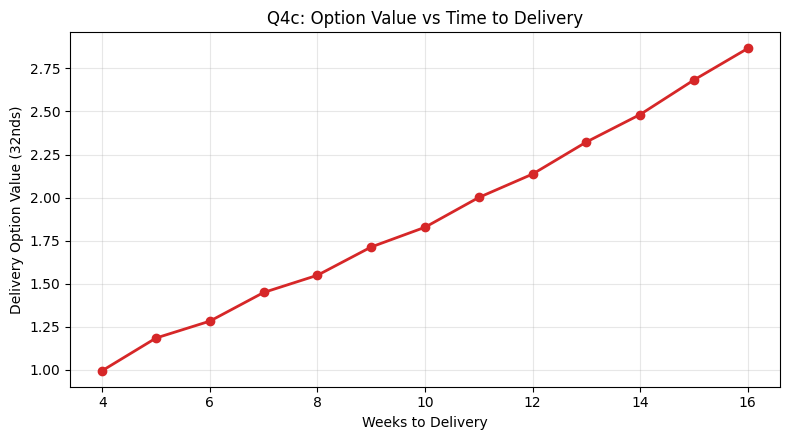

In [38]:
# Q4c: time-to-delivery sensitivity (plot only)
required_vars = [
    'q2_rate_tree_base', 'q2_dt', 'q3_cpn_arr', 'q3_T_rem_arr', 'q3_cf_arr'
 ]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required inputs: {missing}. Please run Q2/Q3 setup cells first.')

from bdt_numpy import futures_delivery_option_tree

q4c_weeks = np.arange(4, 17, dtype=int)
if q4c_weeks.max() >= q2_rate_tree_base.shape[1]:
    raise RuntimeError('Rate tree does not have enough columns for 16-week horizon.')

q4c_option_32 = []
for n_w in q4c_weeks:
    res_w = futures_delivery_option_tree(
        q2_rate_tree_base, q3_cpn_arr, q3_T_rem_arr, q3_cf_arr, n_delivery=int(n_w), dt=q2_dt
    )
    q4c_option_32.append(float(res_w['option_value_32']))

q4c_option_32 = np.array(q4c_option_32, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(q4c_weeks, q4c_option_32, marker='o', linewidth=2, color='tab:red')
ax.set_xlabel('Weeks to Delivery')
ax.set_ylabel('Delivery Option Value (32nds)')
ax.set_title('Q4c: Option Value vs Time to Delivery')
ax.grid(alpha=0.3)
plt.tight_layout()


d) Which sensitivity has the largest impact on option value — volatility, yield level, or time to delivery? Discuss implications for a basis trader who is long the basis (long cash bonds, short futures).


The yield level has the largest practical impact on the delivery option value. While volatility can significantly change the option value in the model, such large volatility shifts are unlikely in practice. By contrast, even a relatively small change in the yield level that moves around the CTD switching point, the option value could differ sharply. Time to delivery has a smaller effect.

For a basis trader, the most important risk comes from changes in the yield level. When yields move close to a CTD switching point, small changes in rates can significantly increase the value of the delivery option, widening the basis. As a result, basis traders need to pay particular attention to whether the yield level is approaching a CTD switching region.

### Question 5: Historical Basis and Model Limitations

**Compare the tree model's predictions to observed basis behavior, especially during stress episodes.**

a) Using `treasury_basis.xlsx`, plot the US (classic bond) net basis from 2016 to 2026. Compute summary statistics (mean, std, min, max) for normal periods vs. stress periods:
   - Sep 2019 repo crisis (Sep 1 – Oct 15, 2019)
   - COVID (Feb 15 – Apr 15, 2020)
   - Fed hiking cycle (2022–2023)

b) Load the TYZ9 stress data (`fut_bond_data_TYZ9_2019-09.xlsx`). Plot the daily net and gross basis during September 2019. Overlay SOFR or repo rates if available in the data. How did the basis behave as repo rates spiked?

c) Overlay the USM6 model option value (from Q3) on the recent USM6 daily basis chart. Does the model option value track the observed net basis? Discuss the magnitude and sign of any discrepancy.

d) **When does the tree model break down?** The model captures delivery optionality, but the observed basis also reflects other forces. Drawing on material from D.4.2, D.4.X.1, and D.5.1, identify what factors beyond delivery optionality drive the basis — especially during the stress episodes you analyzed above. Which factors dominated in each episode? Connect your analysis to the course themes across Ch 4, Ch 5, and Ch 9.

### Question 6: Other Embedded Options and Contract Choice

**Consider delivery options beyond the quality option and how contract design affects option value.**

a) Beyond the quality option modeled above, Treasury futures embed three other delivery options: the **wild-card option** (the short can declare intent to deliver after 2pm at the 2pm settlement price, then choose which bond to deliver based on after-hours price moves), the **timing option** (choosing which day in the delivery month to deliver), and the **end-of-month option** (delivery can occur for several business days after futures trading ends, using the final settlement price). Without modeling these, which would you expect to have the largest quantitative impact? Which the smallest? Explain your reasoning, considering the magnitude of rate moves required and the time windows involved.

b) Our analysis uses the classic bond (US) contract because its wide deliverable basket produces meaningful delivery optionality. For comparison, the 10-year note (TY) contract has a narrow basket at shorter durations, while the ultra bond (WN) has an intermediate basket at very long durations. Using your Q3 results and reasoning about the conversion factor system, rank these three contracts by expected delivery option value and explain what features of the deliverable basket drive the differences.

## 6. Deliverables

Review the [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html) for submission standards, conciseness expectations, and AI usage policy.

Submit a Jupyter notebook with analysis for all six questions (Q1–Q6), including code, figures, and written interpretation. Include a summary section (1–2 paragraphs) synthesizing your findings: How large is the delivery option in the current environment? What drives it? When does the tree model succeed vs. fail in explaining the observed basis?

**Conciseness is a graded criterion** — see [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html).